# Classification Face Expression

## Цель проекта
Построить модель классификации эмоций по изображению лица в оттенках серого и оценить, как на качество и скорость влияют расширение данных, дистиляция и квантизация.

## Что входит в ноутбук
1. Подготовка и проверка датасетов.
2. Обучение базовой модели `ConvNeXtV2 Tiny`.
3. Эксперименты с дополнительным датасетом и объединённой выборкой.
4. Исследование способов ускорения инференса: дистиляция, квантизация и экспорт в ONNX.


In [1]:
import os
import sys

import urllib.request
import zipfile
import time

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchmetrics
import timm
import pytorch_lightning as pl
from torchvision.io import read_image, ImageReadMode
from torch.utils.data import DataLoader, ConcatDataset

import onnx
from torchao.quantization import quantize_, Int8WeightOnlyConfig

sys.path.append(os.path.abspath('..'))

from training import CustomCNNLightning, DistillCNNLightning
from training import init_model, trainer_work, load_from_ckpt
from dataset import Images, download_and_unpack, build_dataloaders, build_transforms

## Конфигурация эксперимента
Фиксируем основные параметры запуска и подготавливаем локальные пути к данным без привязки к Google Colab.

In [2]:
NUM_CLASSES = 7
EPOCHS = 100
BATCH_SIZE = 32

DATA_DIR = Path("unzipped")

FER_URL = "https://www.kaggle.com/api/v1/datasets/download/jonathanoheix/face-expression-recognition-dataset"
YOLO_URL = "https://www.kaggle.com/api/v1/datasets/download/aklimarimi/8-facial-expressions-for-yolo"

MAIN_DIR = DATA_DIR / "images"
YOLO_DIR = DATA_DIR / "9 Facial Expressions you need"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

download_and_unpack(
    FER_URL,
    DATA_DIR / "face-expression-recognition-dataset.zip",
    DATA_DIR,
    marker_dir=MAIN_DIR,
)

print("Активное устройство:", DEVICE)

Датасет уже доступен: unzipped\images
Активное устройство: cuda


## Проверка исходного датасета
Ниже использую класс `Images` из проекта, чтобы быстро посмотреть распределение классов, веса для loss-функции и размер входных изображений.

Сначала проверяю баланс классов на train и validation. Это важно, потому что в наборе данных есть выраженный дисбаланс, особенно для класса `disgust`.

In [3]:
img = Images(MAIN_DIR, seed=1)
print(f'Длина train классов: {img.class_lengths}')
img = Images(MAIN_DIR, train=False, seed=1)
print(f'Длина val классов: {img.class_lengths}')

Длина train классов: {'angry': 3993, 'disgust': 436, 'fear': 4103, 'happy': 7164, 'neutral': 4982, 'sad': 4938, 'surprise': 3205, 'all': 28821}
Длина val классов: {'angry': 960, 'disgust': 111, 'fear': 1018, 'happy': 1825, 'neutral': 1216, 'sad': 1139, 'surprise': 797, 'all': 7066}


In [4]:
img = Images(MAIN_DIR, int_label=True, seed=1)
img.weights

tensor([0.8074, 2.4433, 0.7965, 0.6028, 0.7228, 0.7260, 0.9012],
       device='cuda:0')

In [5]:
print(f'Размер входного изображения: {img[0][0].shape}')

Размер входного изображения: torch.Size([1, 48, 48])


## Базовая модель
В качестве baseline беру `ConvNeXtV2 Tiny` из `timm` и адаптирую её под одноканальные изображения.

Почему эта архитектура:
- достаточно сильная как baseline;
- хорошо поддерживается в `timm`;
- удобно адаптируется под вход из одного канала.

In [6]:
torch.set_float32_matmul_precision("high")

Для fine-tuning размораживаю:
- входной `stem`, чтобы корректно адаптироваться к одному каналу;
- последний stage, чтобы модель могла подстроиться под новую задачу;
- классификационную голову.


In [7]:
model = init_model(NUM_CLASSES, DEVICE)

## Аугментации и подготовка данных
Сначала собираю пайплайн аугментаций без нормализации, чтобы визуально проверить преобразования, а затем добавляю финальную нормализацию для обучения.


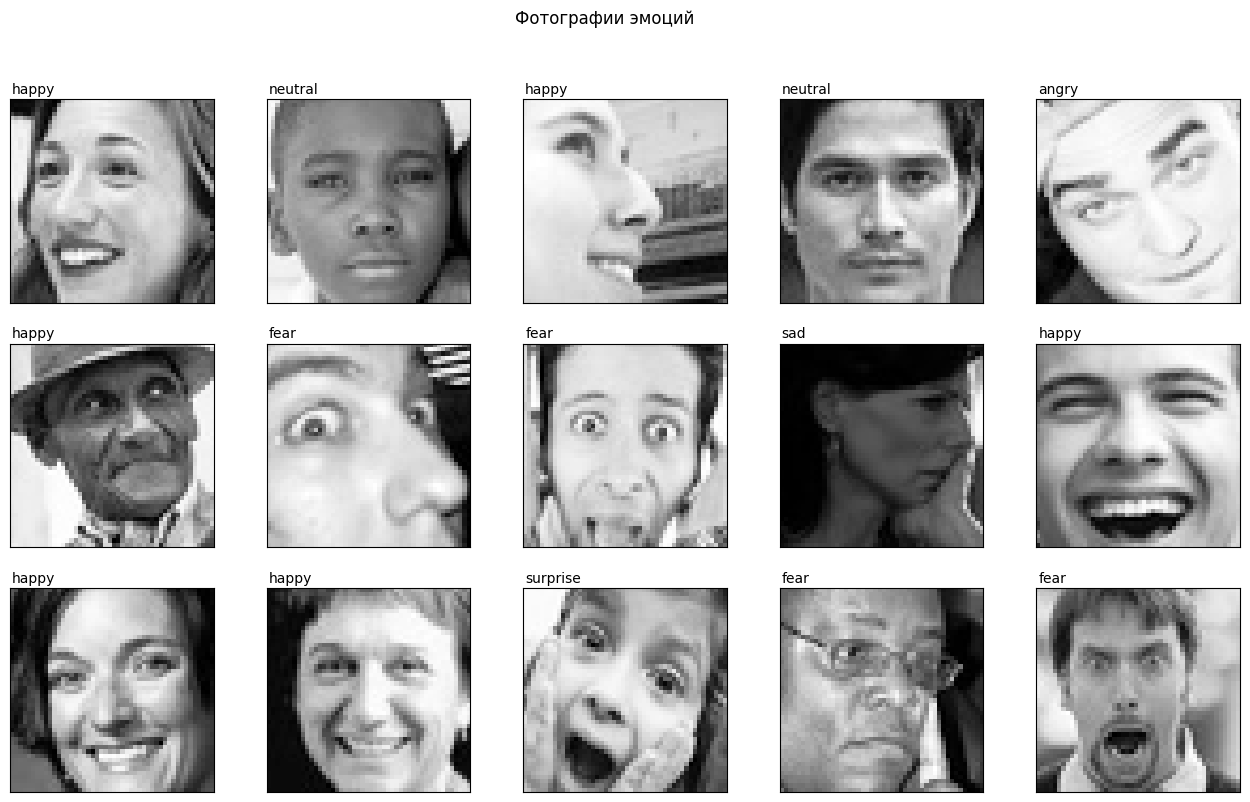

In [8]:
img = Images(
    MAIN_DIR,
    img_mode=ImageReadMode.GRAY,
    seed=1
)
img.show_images(
    suptitle='Фотографии эмоций',
    cmap='Greys_r',
    text_pos=(0, -2)
)

В train-пайплайне использую горизонтальный флип, небольшую перспективную деформацию и слабое размытие. Для validation оставляю только преобразования, необходимые для согласования формата входа.


In [9]:
size = model.default_cfg["input_size"][1]
train_transform, valid_transform = build_transforms(
    size,
    augment=True,
    normalize=False,
)

Проверяю, что после preprocessing изображение соответствует ожидаемому размеру модели.

In [10]:
train_transform(img[0][0]).shape, valid_transform(img[0][0]).shape

(torch.Size([1, 224, 224]), torch.Size([1, 224, 224]))

Визуально контролирую, что аугментации не искажают изображение до нечитабельного состояния.

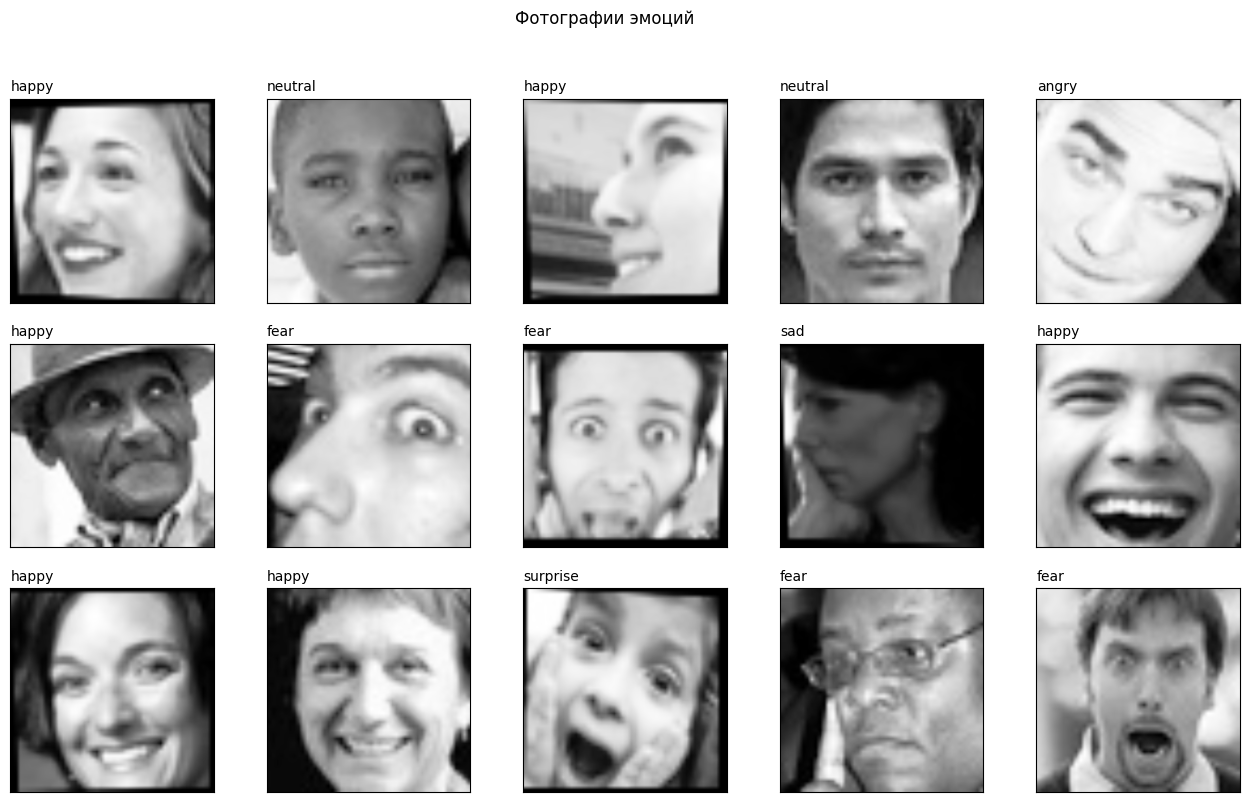

In [11]:
img = Images(
    MAIN_DIR,
    transform=train_transform,
    img_mode=ImageReadMode.GRAY,
    seed=1
)
img.show_images(
    suptitle='Фотографии эмоций',
    cmap='Greys_r',
    text_pos=(0, -10)
)

После визуальной проверки включаю нормализацию. Этот вариант уже используется для обучения.

In [12]:
train_transform, valid_transform = build_transforms(
    size,
    augment=True,
    normalize=True,
)


Формирую `Dataset` и `DataLoader` для train и validation.

In [13]:
train_dt, valid_dt, train_dl, valid_dl = build_dataloaders(
    MAIN_DIR,
    batch_size=BATCH_SIZE,
    train_transform=train_transform,
    valid_transform=valid_transform,
    num_workers=2,
    img_mode=ImageReadMode.GRAY
)

На последнем шаге ещё раз смотрю, что уже готовые батчи выглядят корректно.

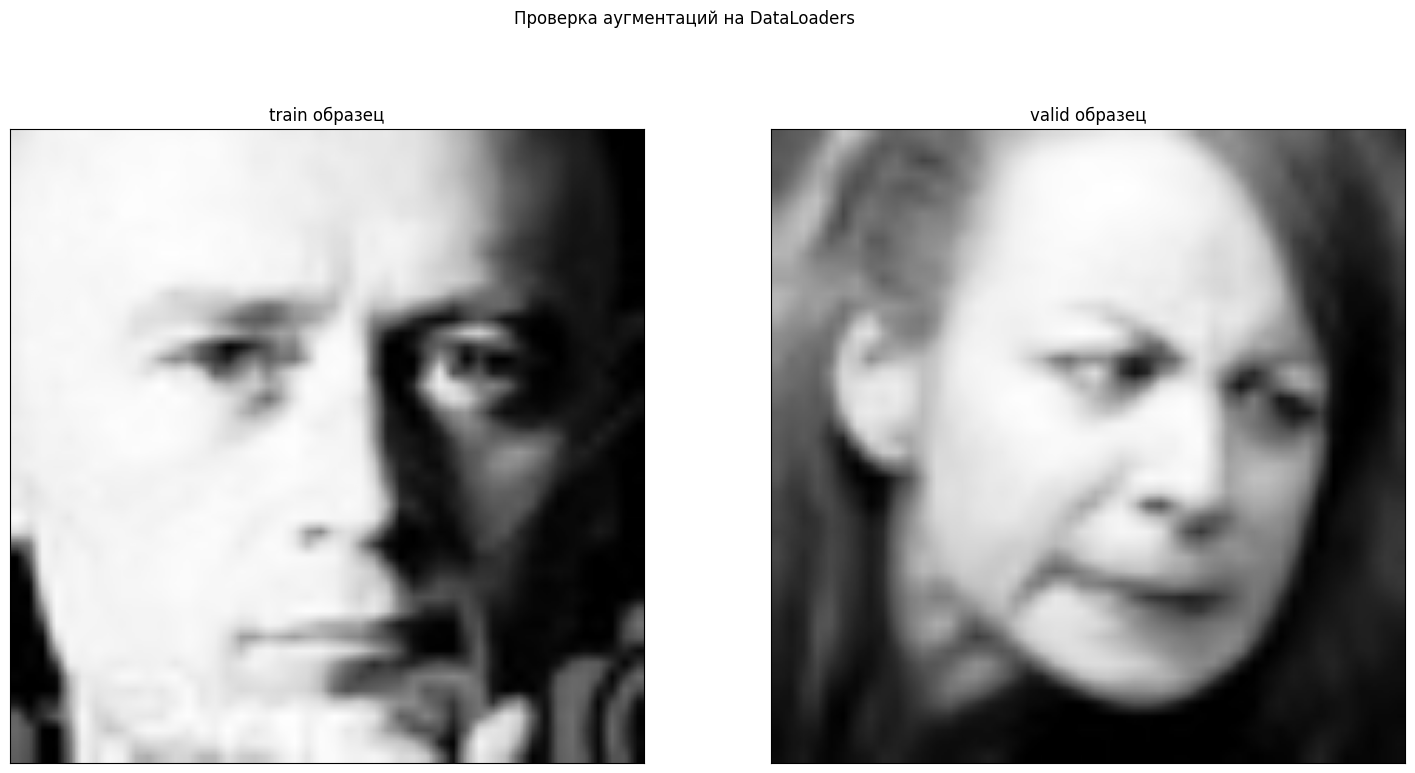

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(18, 9))

loaders_to_compare = [
    ('train образец', train_dl), 
    ('valid образец', valid_dl)
]

for i, (name, dl) in enumerate(loaders_to_compare):
    sample = next(iter(dl))[0][0]
    ax[i].imshow(img._tensor_to_PIL(sample), cmap='Greys_r')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_title(name)

fig.suptitle('Проверка аугментаций на DataLoaders');

## Обучение базовой модели

Для обучения использую `PyTorch Lightning`: так код эксперимента остаётся компактным, а логика ранней остановки, чекпоинтов и валидации вынесена в единый пайплайн.

Блок ниже запускает основной fine-tuning baseline-модели.

In [15]:
pl_model = CustomCNNLightning(model, train_dt.weights, NUM_CLASSES)
trainer_work(
    pl_model=pl_model,
    train_dl=train_dl,
    valid_dl=valid_dl,
    filename='best-{epoch}',
    num_epochs=EPOCHS,
    train=True
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
e:\Портфолио\env\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ConvNeXt           │ 27.9 M │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 15.5 M                                                                                           
Non-trainable params: 12.4 M                                                                                       
Total params: 27.9 M                                                                                               
Total estimated model params size (MB): 111                                                                        
Modules in train mode: 252                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric valid_loss improved. New best score: 1.066


Metric valid_loss improved by 0.086 >= min_delta = 0.0. New best score: 0.979


Metric valid_loss improved by 0.062 >= min_delta = 0.0. New best score: 0.917


Metric valid_loss improved by 0.019 >= min_delta = 0.0. New best score: 0.898


Monitored metric valid_loss did not improve in the last 5 records. Best score: 0.898. Signaling Trainer to stop.


## Эксперимент 1. Расширение данных дополнительным датасетом

По итогам первых прогонов стало ясно, что baseline ограничен качеством данных:
- классы распределены неравномерно;
- часть изображений сложно различима даже визуально;
- объём исходного набора умеренный для задачи на 7 классов.

Поэтому я проверяю гипотезу, что дополнительный датасет со схожими метками поможет улучшить обобщающую способность модели.

## Загрузка дополнительного датасета

In [19]:
download_and_unpack(
    YOLO_URL,
    DATA_DIR / "8-facial-expressions-for-yolo.zip",
    DATA_DIR,
    marker_dir=YOLO_DIR,
)

Датасет уже доступен: unzipped\9 Facial Expressions you need


## Трансформации для второго датасета
Во втором наборе данные уже частично аугментированы, поэтому на этом этапе оставляю только базовое приведение к формату модели.


In [20]:
model = init_model(NUM_CLASSES, DEVICE)
size = model.default_cfg["input_size"][1]
train_transform, valid_transform = build_transforms(
    size,
    augment=False,
    normalize=False,
)

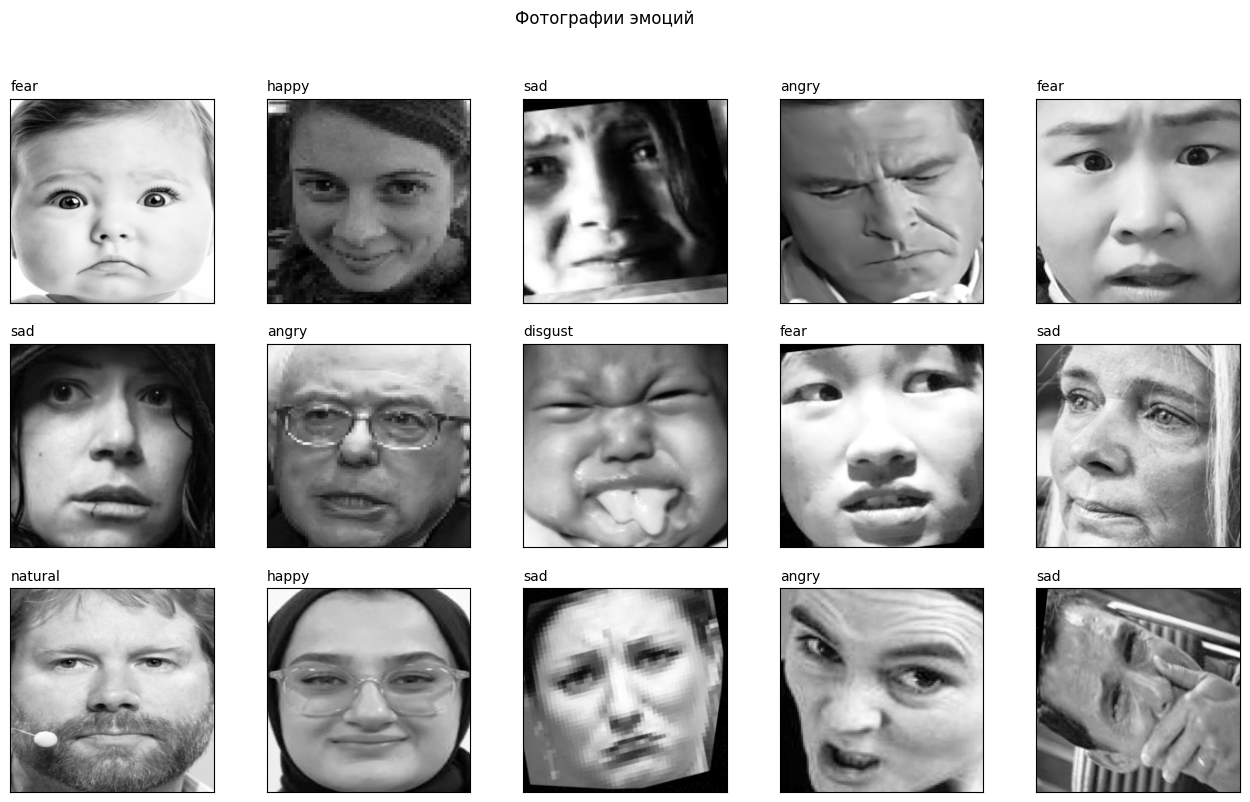

In [21]:
dt = Images(
    YOLO_DIR,
    yolo=True,
    transform=train_transform,
    img_mode=ImageReadMode.GRAY,
    seed=1
)
dt.show_images(
    suptitle='Фотографии эмоций',
    cmap='Greys_r',
    text_pos=(0, -10)
)

In [22]:
train_transform, valid_transform = build_transforms(
    size,
    augment=False,
    normalize=True,
)


## Обучение на дополнительном датасете

In [23]:
train_yolo_dt, valid_yolo_dt, train_yolo_dl, valid_yolo_dl = build_dataloaders(
    YOLO_DIR,
    batch_size=BATCH_SIZE,
    train_transform=train_transform,
    valid_transform=valid_transform,
    num_workers=2,
    img_mode=ImageReadMode.GRAY,
    yolo=True,
)

In [21]:
pl_model = CustomCNNLightning(model, train_yolo_dt.weights, NUM_CLASSES)
trainer_work(
    pl_model=pl_model,
    train_dl=train_yolo_dl,
    valid_dl=valid_yolo_dl,
    filename='best-{epoch}',
    num_epochs=EPOCHS,
    train=True
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ConvNeXt           │ 27.9 M │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 15.5 M                                                                                           
Non-trainable params: 12.4 M                                                                                       
Total params: 27.9 M                                                                                               
Total estimated model params size (MB): 111                                                                        
Modules in train mode: 252                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric valid_loss improved. New best score: 0.590


Metric valid_loss improved by 0.076 >= min_delta = 0.0. New best score: 0.514


Metric valid_loss improved by 0.009 >= min_delta = 0.0. New best score: 0.505


Monitored metric valid_loss did not improve in the last 5 records. Best score: 0.505. Signaling Trainer to stop.


## Эксперимент 2. Объединение датасетов
Ещё одна гипотеза: объединённая выборка может дать более устойчивую модель за счёт большего разнообразия примеров.

## Обучение на объединённой выборке

Объединяю train и validation части обоих датасетов и пересчитываю веса классов для новой обучающей выборки.

In [24]:
train_full_dt = ConcatDataset([train_dt, train_yolo_dt])
train_full_dl = DataLoader(train_full_dt, batch_size=BATCH_SIZE,
                      shuffle=True, num_workers=2,
                      pin_memory=True)

valid_full_dt = ConcatDataset([valid_dt, valid_yolo_dt])
valid_full_dl = DataLoader(valid_full_dt, batch_size=BATCH_SIZE, num_workers=2,
                      pin_memory=True)

In [25]:
weights = [
    train_dt.class_lengths[class_idx] + train_yolo_dt.class_lengths[class_idx]
    for class_idx in range(NUM_CLASSES)
]
weights

[15186, 4732, 9461, 20995, 10645, 16907, 4256]

In [26]:
weights = 1 / torch.sqrt(torch.tensor(weights, dtype=torch.float32))
weights = weights / weights.mean()
weights = weights.to(DEVICE)
weights

tensor([0.7830, 1.4027, 0.9920, 0.6659, 0.9352, 0.7421, 1.4791],
       device='cuda:0')

In [25]:
model = init_model(NUM_CLASSES, DEVICE)
pl_model = CustomCNNLightning(model, weights, NUM_CLASSES)
trainer_work(
    pl_model=pl_model,
    train_dl=train_full_dl,
    valid_dl=valid_full_dl,
    filename='best-{epoch}',
    num_epochs=EPOCHS,
    train=True
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ConvNeXt           │ 27.9 M │ train │     0 │
│ 1 │ loss      │ CrossEntropyLoss   │      0 │ train │     0 │
│ 2 │ train_acc │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ valid_acc │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 15.5 M                                                                                           
Non-trainable params: 12.4 M                                                                                       
Total params: 27.9 M                                                                                               
Total estimated model params size (MB): 111                                                                        
Modules in train mode: 252                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

e:\Портфолио\env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


Output()

...

Metric valid_loss improved. New best score: 1.016


Metric valid_loss improved by 0.080 >= min_delta = 0.0. New best score: 0.936


Metric valid_loss improved by 0.077 >= min_delta = 0.0. New best score: 0.858


Metric valid_loss improved by 0.010 >= min_delta = 0.0. New best score: 0.848


Monitored metric valid_loss did not improve in the last 5 records. Best score: 0.848. Signaling Trainer to stop.


## Промежуточные выводы

По текущим прогонам объединённый датасет не дал настолько убедительного выигрыша, чтобы оправдать усложнение пайплайна. Для дальнейших экспериментов удобнее оставить базовый FER-подобный набор как основной источник данных и уже на нём исследовать оптимизацию модели.

In [28]:
base_path = "lightning_logs/"
models_names = {
    "ferdt": f"{base_path}version_0/checkpoints/best-epoch=4.ckpt",
    "yolodt": f"{base_path}version_1/checkpoints/best-epoch=2.ckpt",
    "fulldt": f"{base_path}version_2/checkpoints/best-epoch=3.ckpt",
}

for model_name, path in models_names.items():
    model = init_model(NUM_CLASSES, DEVICE, finetuning=False)
    model = load_from_ckpt(model, path, DEVICE)

    pl_model = CustomCNNLightning(model, weights, NUM_CLASSES)
    print(f"---- {model_name} ----")
    trainer_work(
        pl_model=pl_model,
        train_dl=train_full_dl,
        valid_dl=valid_full_dl,
        filename="best-{epoch}",
        num_epochs=EPOCHS,
        train=False,
    )

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


missing: []
unexpected: ['loss.weight']
---- ferdt ----


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         valid_acc         │    0.6541193127632141     │
│        valid_loss         │    1.0275441408157349     │
└───────────────────────────┴───────────────────────────┘

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         valid_acc         │     0.521425187587738     │
│        valid_loss         │     1.82433021068573      │
└───────────────────────────┴───────────────────────────┘

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


missing: []
unexpected: ['loss.weight']
---- fulldt ----


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         valid_acc         │    0.6930634379386902     │
│        valid_loss         │     0.847813606262207     │
└───────────────────────────┴───────────────────────────┘

## Оптимизация модели
После оценки качества пробую уменьшить стоимость инференса за счёт дистиляции и квантизации.

Параметры для подбора в self-made grid search: `alpha` отвечает за баланс между soft-targets и обычной cross-entropy, `temperature` сглаживает распределение логитов учителя.

In [15]:
alphas = [0.99, 0.95, 0.5, 0.1, 0.05]
temperatures = [20., 10., 8., 6., 4.5, 3., 2., 1.5]

In [16]:
base_path = "lightning_logs/"
model_name = "ferdt"
path = f"{base_path}version_0/checkpoints/best-epoch=4.ckpt"

In [ ]:
results = []
for alpha in alphas:
    for temperature in temperatures:
        student_model = timm.create_model(
            "mobilenetv3_small_100",
            pretrained=True,
            num_classes=NUM_CLASSES,
            in_chans=1,
        )
        teacher_model = init_model(NUM_CLASSES, DEVICE, finetuning=False)
        teacher_model = load_from_ckpt(teacher_model, path, DEVICE)

        pl_model = DistillCNNLightning(
            student_model,
            teacher_model,
            alpha,
            temperature,
            train_dt.weights,
            NUM_CLASSES,
        )

        trainer_work(
            pl_model=pl_model,
            train_dl=train_dl,
            valid_dl=valid_dl,
            filename=f"best-{alpha}-{temperature}-{{epoch}}",
            num_epochs=5,
            train=True,
        )

        results.append(
            {
                "alpha": alpha,
                "temperature": temperature,
                "best_accuracy": pl_model.best_accuracy.item(),
                "best_loss": pl_model.best_loss.item(),
                "best_epoch": pl_model.best_epoch,
            }
        )

        print(f"Best for alpha={alpha}, temp={temperature}:")
        print(f"Accuracy: {pl_model.best_accuracy.item():.4f}")
        print(f"Loss: {pl_model.best_loss.item():.4f}")
        print(f"Epoch: {pl_model.best_epoch}")

best_result = max(results, key=lambda item: item["best_accuracy"])
print(
    f"\nBest params: alpha={best_result['alpha']}, "
    f"temp={best_result['temperature']}"
)
print(f"Best accuracy: {best_result['best_accuracy']:.4f}")


e:\Портфолио\classification\training.py:208: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=device)
Using 16bit Automatic Mixed Precision

missing: []
unexpected: ['loss.weight']


e:\Портфолио\env\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ student_model │ MobileNetV3        │  1.5 M │ train │     0 │
│ 1 │ teacher_model │ ConvNeXt           │ 27.9 M │ eval  │     0 │
│ 2 │ train_acc     │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ valid_acc     │ MulticlassAccuracy │      0 │ train │     0 │
└───┴───────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 27.9 M                                                                                       
Total params: 29.4 M                                                                                               
Total estimated model params size (MB): 117                                                                        
Modules in train mode: 237                                                                                         
Modules in eval mode: 249                                                                                          
Total FLOPs: 0

e:\Портфолио\env\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:534: Found 249 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Output()

Metric valid_loss improved. New best score: 1.066


Запускаю distillation с лучшими найденными гиперпараметрами.

In [ ]:
student_model = timm.create_model(
    "mobilenetv3_small_100",
    pretrained=True,
    num_classes=NUM_CLASSES,
    in_chans=1,
).to(DEVICE)

teacher_model = init_model(NUM_CLASSES, DEVICE, finetuning=False)
teacher_model = load_from_ckpt(teacher_model, path, DEVICE)

pl_model = DistillCNNLightning(
    student_model,
    teacher_model,
    best_result["alpha"],
    best_result["temperature"],
    weights,
    NUM_CLASSES,
)

trainer_work(
    pl_model=pl_model,
    train_dl=train_dl,
    valid_dl=valid_dl,
    filename="best-{epoch}",
    num_epochs=EPOCHS,
    train=True,
)

model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

NameError: name 'load_from_ckpt' is not defined

Сравниваю исходную и student-модель по скорости валидации и потреблению памяти.

In [ ]:
model_compare = []

for model_name, model in [("orig_model", teacher_model), ("student_model", student_model)]:
    print(model_name)
    start_time = time.perf_counter()
    pl_model = CustomCNNLightning(model, weights, NUM_CLASSES)
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()
    trainer_work(
        pl_model=pl_model,
        train_dl=train_full_dl,
        valid_dl=valid_full_dl,
        filename="best-{epoch}",
        num_epochs=EPOCHS,
        train=False,
    )
    val_time = f"{time.perf_counter() - start_time:.3f}"
    val_mem = (
        f"{torch.cuda.max_memory_allocated() / 1024**2:.3f}MB"
        if DEVICE == "cuda"
        else None
    )
    model_compare.append([model_name, val_time, val_mem])
    print(f"Duration on validate: {val_time}")
    print(f"Max memory allocated: {val_mem}")

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/slipernik/ml/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


orig_model
Validation DataLoader 0: 100%|████████████████████████████████████████████████████████| 264/264 [00:19<00:00, 13.87it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        valid_acc            0.654356062412262
       valid_loss           1.0200165510177612
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Duration on validate: 19.141
Max memory allocated: 905.697265625MB
student_model
Validation DataLoader 0: 100%|████████████████████████████████████████████████████████| 264/264 [00:08<00:00, 32.89it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        valid_acc           0.12357954680919647
       valid_loss            7.668262004852295
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Duration on validate: 8.104
Max memory allocated: 361.97265625MB


## Квантизация
Пробую два сценария:
- `torchao.quantize_` для весовой квантизации;
- `torch.quantization.quantize_dynamic` для CPU-версии модели.

Ниже сравниваю оба варианта с исходной моделью. Для CPU-квантизации явно запускаю validation на CPU, чтобы поведение было воспроизводимым.

In [ ]:
orig_model = init_model(NUM_CLASSES, DEVICE, finetuning=False)
quantized_model = load_from_ckpt(orig_model, path, DEVICE)
quantize_(quantized_model, Int8WeightOnlyConfig())

start_time = time.perf_counter()
pl_model = CustomCNNLightning(quantized_model, weights, NUM_CLASSES)
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
trainer_work(
    pl_model=pl_model,
    train_dl=train_dl,
    valid_dl=valid_dl,
    filename="best-{epoch}",
    num_epochs=EPOCHS,
    train=False,
)
val_time = f"{time.perf_counter() - start_time:.3f}"
val_mem = (
    f"{torch.cuda.max_memory_allocated() / 1024**2:.3f}MB"
    if DEVICE == "cuda"
    else None
)
model_compare.append(["quantized_gpu_model", val_time, val_mem])
print(f"Duration on validate: {val_time}")
print(f"Max memory allocated: {val_mem}")

Using 16bit Automatic Mixed Precision (AMP)
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


missing: []
unexpected: ['loss.weight']
Validation DataLoader 0: 100%|████████████████████████████████████████████████████████| 264/264 [00:21<00:00, 12.21it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        valid_acc           0.5223721861839294
       valid_loss                   nan
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Duration on validate: 21.744
Max memory allocated: 825.85302734375MB


In [ ]:
orig_model = init_model(NUM_CLASSES, DEVICE, finetuning=False)
orig_model = load_from_ckpt(orig_model, path, DEVICE)
quantized_model = torch.quantization.quantize_dynamic(
    orig_model.cpu().eval(),
    {torch.nn.Linear},
    dtype=torch.qint8,
)
cpu_weights = weights.cpu()

start_time = time.perf_counter()
pl_model = CustomCNNLightning(quantized_model, cpu_weights, NUM_CLASSES)
trainer_work(
    pl_model=pl_model,
    train_dl=train_dl,
    valid_dl=valid_dl,
    filename="best-{epoch}",
    num_epochs=EPOCHS,
    train=False,
    accelerator="cpu",
    precision="32-true",
)
val_time = f"{time.perf_counter() - start_time:.3f}"
model_compare.append(["quantized_cpu_model", val_time, None])
print(f"Duration on validate: {val_time}")

missing: []
unexpected: ['loss.weight']


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
/home/slipernik/ml/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:175: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Validation DataLoader 0: 100%|████████████████████████████████████████████████████████| 264/264 [06:22<00:00,  0.69it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        valid_acc           0.6239346861839294
       valid_loss            1.100547432899475
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Duration on validate: 382.305


## Сводная таблица по инференсу

In [ ]:
pd.DataFrame(data=model_compare, columns=['model_name', 'val_time', 'val_mem'])

,model_name,val_time,val_mem
0,orig_model,19.141,905.697265625MB
1,student_model,8.104,361.97265625MB
2,quantized_gpu_model,21.744,825.85302734375MB
3,quantized_cpu_model,382.305,None


## Экспорт в ONNX
Сохраняю student-модель в ONNX-формате, чтобы дальше можно было использовать её для инференса.

In [ ]:
student_model_for_export = student_model.cpu().eval()
example_input = torch.randn(1, 1, 224, 224)

torch.onnx.export(
    student_model_for_export,
    example_input,
    "student_model.onnx",
    export_params=True,
    input_names=["image"],
    output_names=["logits"],
    dynamic_axes={"image": {0: "batch"}, "logits": {0: "batch"}},
)

In [ ]:
onnx_model = onnx.load('student_model.onnx')
print('Input: ', onnx_model.graph.input, '\n')
print('Output: ', onnx_model.graph.output, '\n')
print('Layer 0: ', onnx_model.graph.node[0], '\n')

<h1>Финальный вывод</h1> (ПОПРАВИТЬ)

В целом дистиляция показал себя, как очень эффективный способ для снижения ресурсозатратности модели. С квантизацией, к сожалению, такого сказать не могу. По точность, возможно были способы извлечь более лучший процент, но склоняюсь к тому, что примеры являются трудноразличимыми (в целом мы в реальной жизни сами с трудом считываем чужие эмоции).

P.S. Прошу прощения, что работа оформлена рвано. Делал очень много прогонов (пробы/ошибки), чтобы получить приемлимый результат. Стоило еще применить другие метрики. Также можно было многие вещи в более акуратные функции обернуть, что не плодить дублетный код.